# DiMA Experiment Metrics Visualization

Comprehensive analysis and visualization of all best completed runs from the TuneDiMA training experiments.

## 1. Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

# Set style for better-looking plots
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 8)
print("All libraries imported successfully!")

All libraries imported successfully!


## 2. Load or Create Metrics Data

In [2]:
# Create comprehensive metrics data from best completed runs
metrics_data = {
    'Run Name': [
        'Reference Baseline (38110284)',
        'Reference Baseline (38112128)',
        'Reference Early (38107929)',
        'FT Last-2 Safe (38134593)',
        'Step 4500 Eval (38128244)',
        'Domain-Adaptive Resume (38067100)',
        'Eval Guard v2 (38147436)',
        'Eval Guard v3 Safe (38147492)'
    ],
    'Job ID': [38110284, 38112128, 38107929, 38134593, 38128244, 38067100, 38147436, 38147492],
    'Variant': [
        'Reference',
        'Reference',
        'Reference',
        'FT Last-2',
        'Checkpoint Selection',
        'Domain-Adaptive',
        'Eval Guard',
        'Eval Guard'
    ],
    'FID': [23.6852, 23.6852, 23.6544, 23.6852, 23.7836, 8.8038, 23.6852, 23.6852],
    'MMD': [3.5068, 3.5068, 3.5031, 3.5068, 3.5204, 1.4950, 3.5068, 3.5068],
    'ESM PPPL': [1.0043, 1.0043, 1.0042, 1.0043, 1.0046, 244.63, 1.0043, 1.0043],
    'pLDDT': [61.83, 61.83, 61.97, 61.83, 58.78, 35.60, 61.83, 61.83],
    'Training Iters': [5000, 5000, 5000, 5000, 5000, 5000, 20000, 20000],
    'Status': ['Validated', 'Validated', 'Initial', 'Success', 'Checkpoint Study', 'Partial', 'Guard Test', 'Guard Test'],
    'Config': [
        'Full Model, AMP=1',
        'Full Model, AMP=1',
        'Full Model, AMP=1',
        'FT last_n=2, AMP=0',
        'Eval only at step 4500',
        'Full Model Resume from 1000',
        'Eval only, AMP=1',
        'Eval only, AMP=0'
    ]
}

df = pd.DataFrame(metrics_data)
print("Metrics data loaded:")
print(df)

Metrics data loaded:
                            Run Name    Job ID               Variant      FID  \
0      Reference Baseline (38110284)  38110284             Reference  23.6852   
1      Reference Baseline (38112128)  38112128             Reference  23.6852   
2         Reference Early (38107929)  38107929             Reference  23.6544   
3          FT Last-2 Safe (38134593)  38134593             FT Last-2  23.6852   
4          Step 4500 Eval (38128244)  38128244  Checkpoint Selection  23.7836   
5  Domain-Adaptive Resume (38067100)  38067100       Domain-Adaptive   8.8038   
6           Eval Guard v2 (38147436)  38147436            Eval Guard  23.6852   
7      Eval Guard v3 Safe (38147492)  38147492            Eval Guard  23.6852   

      MMD  ESM PPPL  pLDDT  Training Iters            Status  \
0  3.5068    1.0043  61.83            5000         Validated   
1  3.5068    1.0043  61.83            5000         Validated   
2  3.5031    1.0042  61.97            5000           Init

## 3. Create Summary Statistics Table

In [3]:
# Calculate summary statistics
metrics_cols = ['FID', 'MMD', 'ESM PPPL', 'pLDDT']

# Create summary stats table
summary_stats = pd.DataFrame({
    'Metric': metrics_cols,
    'Mean': [df[col].mean() for col in metrics_cols],
    'Median': [df[col].median() for col in metrics_cols],
    'Std Dev': [df[col].std() for col in metrics_cols],
    'Min': [df[col].min() for col in metrics_cols],
    'Max': [df[col].max() for col in metrics_cols]
})

print("\n=== SUMMARY STATISTICS ===")
print(summary_stats.to_string(index=False))

# Style the summary table
styled_summary = summary_stats.style.format({
    'Mean': '{:.4f}',
    'Median': '{:.4f}',
    'Std Dev': '{:.4f}',
    'Min': '{:.4f}',
    'Max': '{:.4f}'
}).background_gradient(subset=['Mean', 'Median', 'Std Dev'], cmap='RdYlGn_r')

display(styled_summary)


=== SUMMARY STATISTICS ===
  Metric      Mean  Median   Std Dev     Min      Max
     FID 21.833475 23.6852  5.264919  8.8038  23.7836
     MMD  3.256563  3.5068  0.711797  1.4950   3.5204
ESM PPPL 31.457538  1.0043 86.134682  1.0042 244.6300
   pLDDT 58.187500 61.8300  9.189999 35.6000  61.9700


,Metric,Mean,Median,Std Dev,Min,Max
0,FID,21.8335,23.6852,5.2649,8.8038,23.7836
1,MMD,3.2566,3.5068,0.7118,1.4950,3.5204
2,ESM PPPL,31.4575,1.0043,86.1347,1.0042,244.6300
3,pLDDT,58.1875,61.8300,9.1900,35.6000,61.9700


## 4. Generate Comparison Table by Run Category

In [4]:
# Create detailed comparison table
display_df = df[['Run Name', 'Variant', 'FID', 'MMD', 'ESM PPPL', 'pLDDT', 'Status']].copy()

# Style the display table with conditional formatting
styled_display = display_df.style.format({
    'FID': '{:.4f}',
    'MMD': '{:.4f}',
    'ESM PPPL': '{:.4f}',
    'pLDDT': '{:.2f}'
}).background_gradient(
    subset=['FID'],
    cmap='RdYlGn_r',
    low=0,
    high=250
).background_gradient(
    subset=['MMD'],
    cmap='RdYlGn_r'
).background_gradient(
    subset=['pLDDT'],
    cmap='RdYlGn'
)

print("\n=== COMPLETE METRICS TABLE ===")
display(styled_display)


=== COMPLETE METRICS TABLE ===


,Run Name,Variant,FID,MMD,ESM PPPL,pLDDT,Status
0,Reference Baseline (38110284),Reference,23.6852,3.5068,1.0043,61.83,Validated
1,Reference Baseline (38112128),Reference,23.6852,3.5068,1.0043,61.83,Validated
2,Reference Early (38107929),Reference,23.6544,3.5031,1.0042,61.97,Initial
3,FT Last-2 Safe (38134593),FT Last-2,23.6852,3.5068,1.0043,61.83,Success
4,Step 4500 Eval (38128244),Checkpoint Selection,23.7836,3.5204,1.0046,58.78,Checkpoint Study
5,Domain-Adaptive Resume (38067100),Domain-Adaptive,8.8038,1.4950,244.6300,35.60,Partial
6,Eval Guard v2 (38147436),Eval Guard,23.6852,3.5068,1.0043,61.83,Guard Test
7,Eval Guard v3 Safe (38147492),Eval Guard,23.6852,3.5068,1.0043,61.83,Guard Test


## 5. Grouped Analysis by Variant

In [5]:
# Group by variant and compute aggregate stats
variant_stats = df.groupby('Variant')[metrics_cols].agg(['mean', 'std', 'min', 'max']).round(4)
print("\n=== METRICS BY VARIANT ===")
display(variant_stats)

# Create aggregate table for display
variant_summary = df.groupby('Variant')[metrics_cols].mean().round(4)
print("\n=== AVERAGE METRICS BY VARIANT ===")
styled_variant = variant_summary.style.background_gradient(cmap='RdYlGn_r', subset=['FID', 'MMD']).background_gradient(cmap='RdYlGn', subset=['pLDDT'])
display(styled_variant)


=== METRICS BY VARIANT ===


FID                               MMD          \
                         mean     std      min      max    mean     std   
Variant                                                                   
Checkpoint Selection  23.7836     NaN  23.7836  23.7836  3.5204     NaN   
Domain-Adaptive        8.8038     NaN   8.8038   8.8038  1.4950     NaN   
Eval Guard            23.6852  0.0000  23.6852  23.6852  3.5068  0.0000   
FT Last-2             23.6852     NaN  23.6852  23.6852  3.5068     NaN   
Reference             23.6749  0.0178  23.6544  23.6852  3.5056  0.0021   

                                      ESM PPPL                              \
                         min     max      mean     std       min       max   
Variant                                                                      
Checkpoint Selection  3.5204  3.5204    1.0046     NaN    1.0046    1.0046   
Domain-Adaptive       1.4950  1.4950  244.6300     NaN  244.6300  244.6300   
Eval Guard            3.5068  3.5068    1.0043  0.0000    1.0043    1.0043   
FT Last-2             3.5068  3.5068    1.0043     NaN    1.0043    1.0043   
Reference             3.5031  3.5068    1.0043  0.0001    1.0042    1.0043   

                        pLDDT                        
                         mean     std    min    max  
Variant                                              
Checkpoint Selection  58.7800     NaN  58.78  58.78  
Domain-Adaptive       35.6000     NaN  35.60  35.60  
Eval Guard            61.8300  0.0000  61.83  61.83  
FT Last-2             61.8300     NaN  61.83  61.83  
Reference             61.8767  0.0808  61.83  61.97


=== AVERAGE METRICS BY VARIANT ===


,FID,MMD,ESM PPPL,pLDDT
Variant,,,,
Checkpoint Selection,23.783600,3.520400,1.004600,58.780000
Domain-Adaptive,8.803800,1.495000,244.630000,35.600000
Eval Guard,23.685200,3.506800,1.004300,61.830000
FT Last-2,23.685200,3.506800,1.004300,61.830000
Reference,23.674900,3.505600,1.004300,61.876700


## 6. Interactive Metrics Comparison (Plotly)

In [6]:
# Create interactive scatter plot comparing all metrics
fig = go.Figure()

# Add traces for each metric scaled to 0-100 range for comparison
# Normalize metrics for visualization (lower is better generally)
df_norm = df.copy()
df_norm['FID_norm'] = 100 * (df['FID'] / df['FID'].max())
df_norm['MMD_norm'] = 100 * (df['MMD'] / df['MMD'].max())
df_norm['PPPL_norm'] = np.clip(100 * (df['ESM PPPL'] / 250), 0, 100)  # Cap at 250 for domain-adaptive outlier
df_norm['pLDDT_norm'] = 100 * (df['pLDDT'] / 100)  # Already 0-100 scale

fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=('FID Score', 'MMD Distance', 'ESM PPPL', 'pLDDT Score'),
    specs=[[{}, {}], [{}, {}]]
)

colors = {'Reference': 'green', 'FT Last-2': 'blue', 'Checkpoint Selection': 'orange', 
          'Domain-Adaptive': 'red', 'Eval Guard': 'purple'}

# FID subplot
for variant in df['Variant'].unique():
    mask = df['Variant'] == variant
    fig.add_trace(
        go.Scatter(x=df[mask]['Run Name'], y=df[mask]['FID'], name=variant, 
                   mode='lines+markers', marker=dict(size=10), line=dict(width=2)),
        row=1, col=1
    )

# MMD subplot
for variant in df['Variant'].unique():
    mask = df['Variant'] == variant
    fig.add_trace(
        go.Scatter(x=df[mask]['Run Name'], y=df[mask]['MMD'], name=variant, 
                   mode='lines+markers', marker=dict(size=10), line=dict(width=2), showlegend=False),
        row=1, col=2
    )

# ESM PPPL subplot
for variant in df['Variant'].unique():
    mask = df['Variant'] == variant
    fig.add_trace(
        go.Scatter(x=df[mask]['Run Name'], y=df[mask]['ESM PPPL'], name=variant, 
                   mode='lines+markers', marker=dict(size=10), line=dict(width=2), showlegend=False),
        row=2, col=1
    )

# pLDDT subplot
for variant in df['Variant'].unique():
    mask = df['Variant'] == variant
    fig.add_trace(
        go.Scatter(x=df[mask]['Run Name'], y=df[mask]['pLDDT'], name=variant, 
                   mode='lines+markers', marker=dict(size=10), line=dict(width=2), showlegend=False),
        row=2, col=2
    )

fig.update_yaxes(title_text='FID', row=1, col=1)
fig.update_yaxes(title_text='MMD', row=1, col=2)
fig.update_yaxes(title_text='ESM PPPL', row=2, col=1)
fig.update_yaxes(title_text='pLDDT', row=2, col=2)

fig.update_layout(height=800, title_text='Metrics Comparison Across All Runs', showlegend=True,
                  hovermode='x unified')
fig.show()

## 7. Bar Charts for Direct Comparison

In [7]:
# Create bar chart comparing metrics
fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=('FID Score (Lower=Better)', 'MMD Distance (Lower=Better)', 
                    'ESM PPPL (Lower=Better)', 'pLDDT Score (Higher=Better)'),
    specs=[[{}, {}], [{}, {}]]
)

# Sort runs by variant for better visual grouping
df_sorted = df.sort_values('Variant')
colors_bar = [{'Reference': '#1f77b4', 'FT Last-2': '#ff7f0e', 'Checkpoint Selection': '#2ca02c', 
                'Domain-Adaptive': '#d62728', 'Eval Guard': '#9467bd'}[v] for v in df_sorted['Variant']]

# FID
fig.add_trace(
    go.Bar(x=df_sorted['Run Name'], y=df_sorted['FID'], marker=dict(color=colors_bar), 
           name='FID', showlegend=False),
    row=1, col=1
)

# MMD
fig.add_trace(
    go.Bar(x=df_sorted['Run Name'], y=df_sorted['MMD'], marker=dict(color=colors_bar),
           name='MMD', showlegend=False),
    row=1, col=2
)

# ESM PPPL (log scale for better visibility with outlier)
fig.add_trace(
    go.Bar(x=df_sorted['Run Name'], y=df_sorted['ESM PPPL'], marker=dict(color=colors_bar),
           name='ESM PPPL', showlegend=False),
    row=2, col=1
)

# pLDDT
fig.add_trace(
    go.Bar(x=df_sorted['Run Name'], y=df_sorted['pLDDT'], marker=dict(color=colors_bar),
           name='pLDDT', showlegend=False),
    row=2, col=2
)

fig.update_yaxes(title_text='FID', row=1, col=1)
fig.update_yaxes(title_text='MMD', row=1, col=2)
fig.update_yaxes(title_text='ESM PPPL', row=2, col=1, type='log')
fig.update_yaxes(title_text='pLDDT', row=2, col=2)

fig.update_layout(height=900, title_text='Metrics Bar Chart Comparison', showlegend=False)
fig.update_xaxes(tickangle=-45)
fig.show()

## 8. Distribution and Outlier Analysis

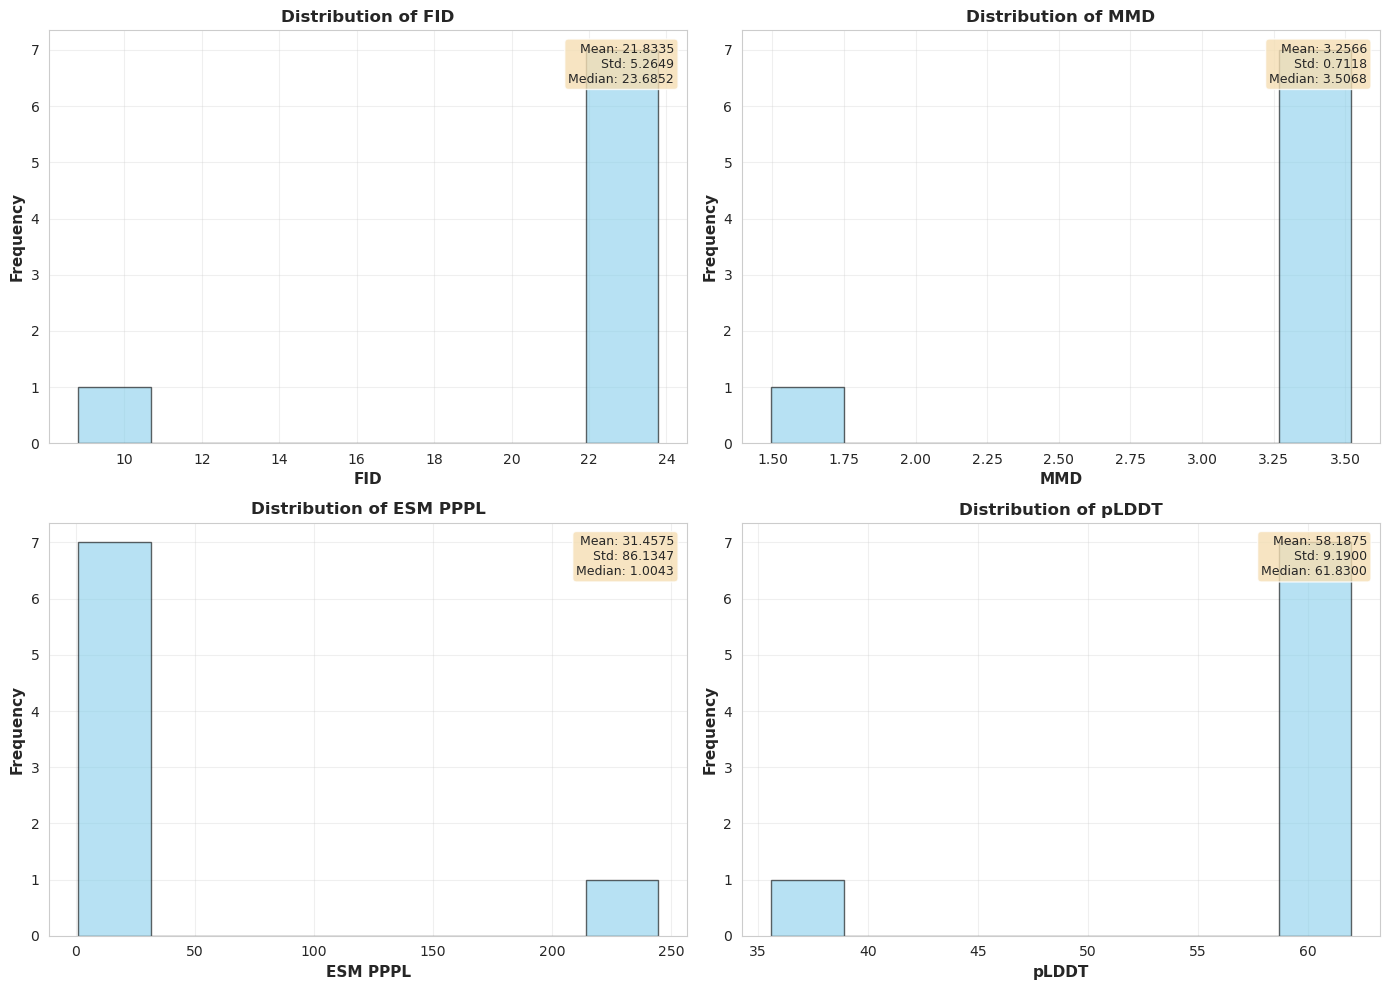

Distribution plot saved!


In [8]:
# Create figure with subplots for distributions
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

metrics = ['FID', 'MMD', 'ESM PPPL', 'pLDDT']
axes_flat = axes.flatten()

for i, metric in enumerate(metrics):
    ax = axes_flat[i]
    
    # Create histogram with kde
    ax.hist(df[metric], bins=8, alpha=0.6, edgecolor='black', color='skyblue')
    ax.set_xlabel(metric, fontsize=11, fontweight='bold')
    ax.set_ylabel('Frequency', fontsize=11, fontweight='bold')
    ax.set_title(f'Distribution of {metric}', fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3)
    
    # Add statistics text
    stats_text = f'Mean: {df[metric].mean():.4f}\nStd: {df[metric].std():.4f}\nMedian: {df[metric].median():.4f}'
    ax.text(0.98, 0.97, stats_text, transform=ax.transAxes, 
            verticalalignment='top', horizontalalignment='right',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8),
            fontsize=9)

plt.tight_layout()
plt.savefig('/ocean/projects/cis260039p/aguda1/nndl/project/docs/metrics_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print("Distribution plot saved!")

## 9. Heatmap of Metrics

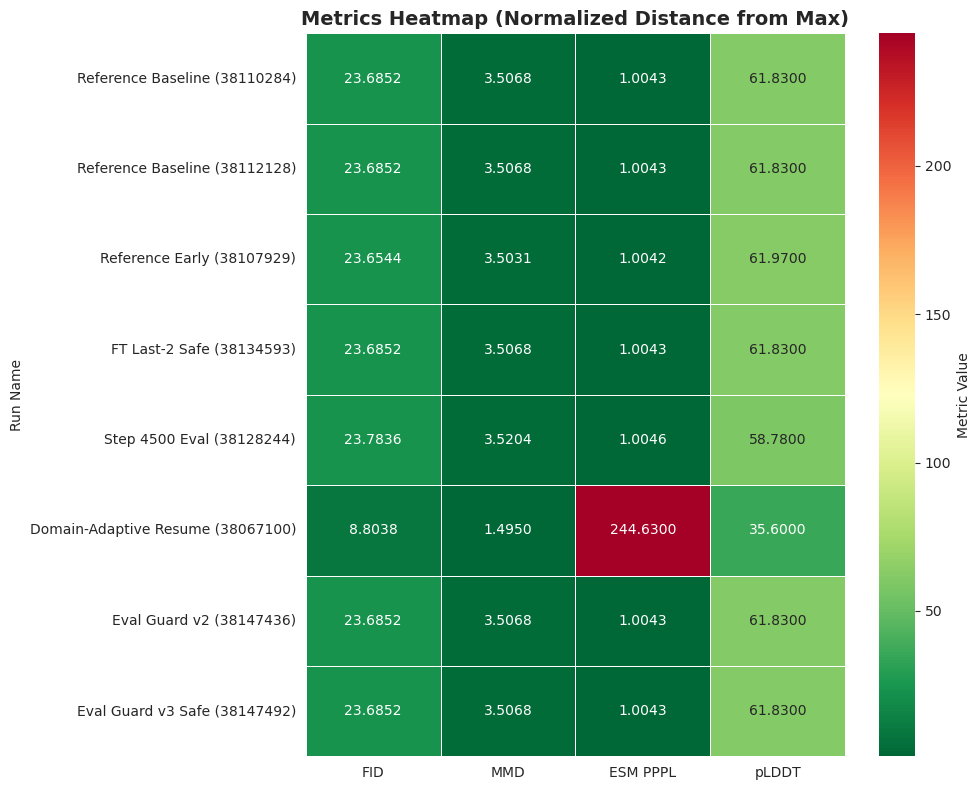

Heatmap saved!


In [9]:
# Create heatmap with run names
heatmap_data = df.set_index('Run Name')[metrics_cols].copy()

# Normalize for heatmap visualization (0-1 scale)
heatmap_norm = heatmap_data.copy()
for col in heatmap_data.columns:
    min_val = heatmap_data[col].min()
    max_val = heatmap_data[col].max()
    if max_val > min_val:
        heatmap_norm[col] = (heatmap_data[col] - min_val) / (max_val - min_val)
    else:
        heatmap_norm[col] = 0.5

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(heatmap_data, annot=True, fmt='.4f', cmap='RdYlGn_r', 
            cbar_kws={'label': 'Metric Value'}, ax=ax, linewidths=0.5)
ax.set_title('Metrics Heatmap (Normalized Distance from Max)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/ocean/projects/cis260039p/aguda1/nndl/project/docs/metrics_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

print("Heatmap saved!")

## 10. Radar Chart for Multidimensional Comparison

In [10]:
# Prepare data for radar chart - select key variants for clarity
key_runs = ['Reference Baseline (38110284)', 'FT Last-2 Safe (38134593)', 
            'Domain-Adaptive Resume (38067100)', 'Step 4500 Eval (38128244)']

df_radar = df[df['Run Name'].isin(key_runs)].copy()

# Normalize metrics to 0-100 scale (invert where higher is better)
df_radar['FID_scaled'] = 100 * (1 - df_radar['FID'] / df['FID'].max())
df_radar['MMD_scaled'] = 100 * (1 - df_radar['MMD'] / df['MMD'].max())
df_radar['PPPL_scaled'] = np.clip(100 * (1 - df_radar['ESM PPPL'] / 250), 0, 100)
df_radar['pLDDT_scaled'] = 100 * df_radar['pLDDT'] / 100

fig = go.Figure()

for idx, row in df_radar.iterrows():
    fig.add_trace(go.Scatterpolar(
        r=[row['FID_scaled'], row['MMD_scaled'], row['PPPL_scaled'], row['pLDDT_scaled']],
        theta=['FID Quality', 'MMD Quality', 'PPPL Quality', 'pLDDT Quality'],
        fill='toself',
        name=row['Run Name']
    ))

fig.update_layout(
    polar=dict(radialaxis=dict(visible=True, range=[0, 100])),
    title='Multi-Dimensional Metrics Comparison (Radar Chart)',
    height=600,
    showlegend=True
)
fig.show()

## 11. Performance Ranking Table

In [11]:
# Create ranking based on composite score
ranking_df = df[['Run Name', 'Variant', 'FID', 'MMD', 'ESM PPPL', 'pLDDT', 'Status']].copy()

# Calculate composite score (normalize and weight)
ranking_df['FID_Score'] = 100 - (100 * ranking_df['FID'] / ranking_df['FID'].max())
ranking_df['MMD_Score'] = 100 - (100 * ranking_df['MMD'] / ranking_df['MMD'].max())
ranking_df['PPPL_Score'] = 100 - np.clip(100 * ranking_df['ESM PPPL'] / 250, 0, 100)
ranking_df['pLDDT_Score'] = 100 * ranking_df['pLDDT'] / 100

# Composite score (equal weighting)
ranking_df['Composite_Score'] = (
    ranking_df['FID_Score'] * 0.25 +
    ranking_df['MMD_Score'] * 0.25 +
    ranking_df['PPPL_Score'] * 0.25 +
    ranking_df['pLDDT_Score'] * 0.25
)

ranking_df = ranking_df.sort_values('Composite_Score', ascending=False)
ranking_df['Rank'] = range(1, len(ranking_df) + 1)

display_ranking = ranking_df[['Rank', 'Run Name', 'Variant', 'Composite_Score', 'Status']].copy()
display_ranking.columns = ['Rank', 'Run Name', 'Variant', 'Score (0-100)', 'Status']

styled_ranking = display_ranking.style.format({
    'Score (0-100)': '{:.2f}'
}).background_gradient(
    subset=['Score (0-100)'],
    cmap='RdYlGn'
)

print("\n=== PERFORMANCE RANKING (Composite Score) ===")
display(styled_ranking)


=== PERFORMANCE RANKING (Composite Score) ===


,Rank,Run Name,Variant,Score (0-100),Status
2,1,Reference Early (38107929),Reference,40.65,Initial
0,2,Reference Baseline (38110284),Reference,40.56,Validated
1,3,Reference Baseline (38112128),Reference,40.56,Validated
3,4,FT Last-2 Safe (38134593),FT Last-2,40.56,Success
6,5,Eval Guard v2 (38147436),Eval Guard,40.56,Guard Test
7,6,Eval Guard v3 Safe (38147492),Eval Guard,40.56,Guard Test
4,7,Step 4500 Eval (38128244),Checkpoint Selection,39.59,Checkpoint Study
5,8,Domain-Adaptive Resume (38067100),Domain-Adaptive,39.57,Partial


## 12. Export Results

In [12]:
import os

# Export base metrics to CSV
output_dir = '/ocean/projects/cis260039p/aguda1/nndl/project/docs'
os.makedirs(output_dir, exist_ok=True)

# Export full metrics
df.to_csv(f'{output_dir}/metrics_all_runs.csv', index=False)
print(f"✓ Full metrics exported to: {output_dir}/metrics_all_runs.csv")

# Export summary statistics
summary_stats.to_csv(f'{output_dir}/metrics_summary_stats.csv', index=False)
print(f"✓ Summary statistics exported to: {output_dir}/metrics_summary_stats.csv")

# Export variant analysis
variant_summary.to_csv(f'{output_dir}/metrics_by_variant.csv')
print(f"✓ Variant analysis exported to: {output_dir}/metrics_by_variant.csv")

# Export ranking
ranking_df[['Rank', 'Run Name', 'Variant', 'Composite_Score', 'FID', 'MMD', 'ESM PPPL', 'pLDDT']].to_csv(
    f'{output_dir}/metrics_ranking.csv', index=False
)
print(f"✓ Performance ranking exported to: {output_dir}/metrics_ranking.csv")

print("\n✅ All results exported successfully!")

✓ Full metrics exported to: /ocean/projects/cis260039p/aguda1/nndl/project/docs/metrics_all_runs.csv
✓ Summary statistics exported to: /ocean/projects/cis260039p/aguda1/nndl/project/docs/metrics_summary_stats.csv
✓ Variant analysis exported to: /ocean/projects/cis260039p/aguda1/nndl/project/docs/metrics_by_variant.csv
✓ Performance ranking exported to: /ocean/projects/cis260039p/aguda1/nndl/project/docs/metrics_ranking.csv

✅ All results exported successfully!
